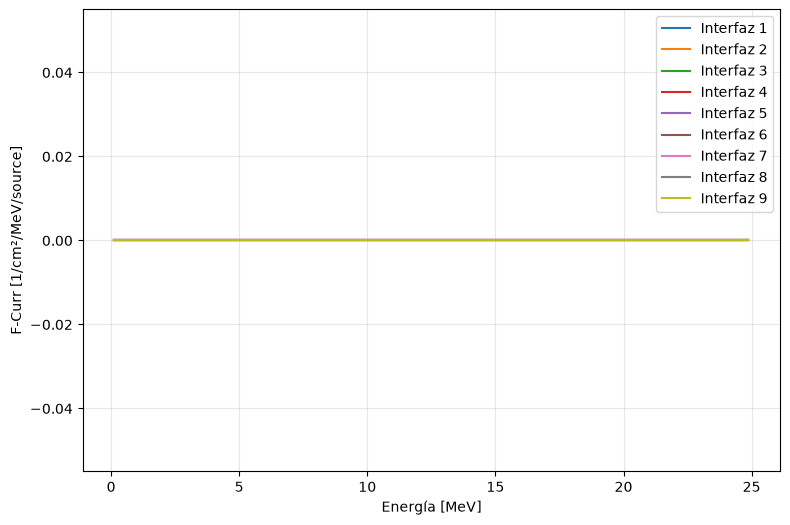

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

archivo = "../out/espectros_CR39.out"

espectros = {}
interfaz_actual = None
leyendo = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        match = re.search(r"no\.\s*=\s*(\d+)\s+reg\s*=\s*(\d+)\s*-\s*(\d+)", linea)

        if match:
            interfaz_actual = int(match.group(1))
            leyendo = False

            if interfaz_actual not in espectros:
                espectros[interfaz_actual] = {
                    "energia": [],
                    "flujo": [],
                    "error": []
                }

        if "#  e-lower" in linea and "proton" in linea:
            leyendo = True
            continue

        if leyendo and interfaz_actual is not None:
            partes = linea.split()

            if len(partes) == 4:
                try:
                    e_lower = float(partes[0])
                    e_upper = float(partes[1])
                    flujo = float(partes[2])
                    rerr = float(partes[3])

                    energia = (e_lower + e_upper) / 2

                    espectros[interfaz_actual]["energia"].append(energia)
                    espectros[interfaz_actual]["flujo"].append(flujo)
                    espectros[interfaz_actual]["error"].append(flujo * rerr)

                except ValueError:
                    pass

plt.figure(figsize=(9, 6))

for interfaz in sorted(espectros):
    energia = np.array(espectros[interfaz]["energia"])
    flujo = np.array(espectros[interfaz]["flujo"])

    plt.plot(
        energia,
        flujo,
        label=f"Interfaz {interfaz}"
    )

plt.xlabel("Energía [MeV]")
plt.ylabel("F-Curr [1/cm²/MeV/source]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

idem que la corriente